# Song Classification
Exploratory data analysis on a Spotify tracks dataset. Evaluating regressor performance and determining the best attributes to use for song popularity prediction.

In [274]:
# imports
import numpy as np
import pandas as pd
import seaborn as sn
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression, SGDRegressor

import plot_utils

## Data Preparation
### A Look at the Dataset
Data source: https://www.kaggle.com/datasets/maharshipandya/-spotify-tracks-dataset    
TODO description of attributes  

### Data Cleaning
Dropped the track id and track name as these are not useful in predictive tasks.  
For histogram generation: converted song duration in ms to minutes, and dropped all entries that were longer than 12 minutes.

In [275]:
songs = pd.read_csv("input_data/dataset.csv")

drop_columns = ["Unnamed: 0", "track_id", "track_name"]
for col in drop_columns:
    songs.pop(col)

key = songs["key"] # TODO check how many entries of key have a value of -1 (means key unknown); cause wanna drop those

# prep data for display in histograms
duration_ms = songs["duration_ms"]
danceability = songs["danceability"]
loudness = songs["loudness"]
instrumentalness = songs["instrumentalness"]

# convert song length in ms to minutes
duration_minutes = [(ms / 1000) / 60 for ms in duration_ms]
# drop all songs 12 mins or longer to clean up histogram
count = 0
for time in duration_minutes:
    if time >= 12:
        count = count + 1
print("Num Songs >= 12 min:", count)
# drop last 301 songs
duration_minutes = sorted(duration_minutes)
duration_minutes = duration_minutes[:(((len(duration_minutes)) - 1) - 301)]

# TODO perform EDA tasks (check if data distribution is normal, etc.)
# TODO normalization is not necessary bc numerical values are already probabilities in a range from 0 to 1
# TODO curious to find out which albums by certain artists are their most popular?

Num Songs >= 12 min: 301


### Exploratory Data Analysis
Using correlation matrix, histograms, scatterplots, and bar plots to view attribute relationships.

#### Correlation Matrix
I was hoping to find some correlations between attributes and popularity, but the strongest was a negative relationship with a correlation coefficient of -0.10 between popularity and instrumentalness. Of the correlations between popularity and other attributes, the lowest are duration_ms, energy, key, liveness and tempo.

Relationships of note:  
* r = -0.73 between energy and acousticness
* r = 0.76 between energy and loudness
* r = -0.59 between acousticness and loudness

Other notes: There may still be significant non-linear relationships between certain attributes and popularity.

<AxesSubplot:>

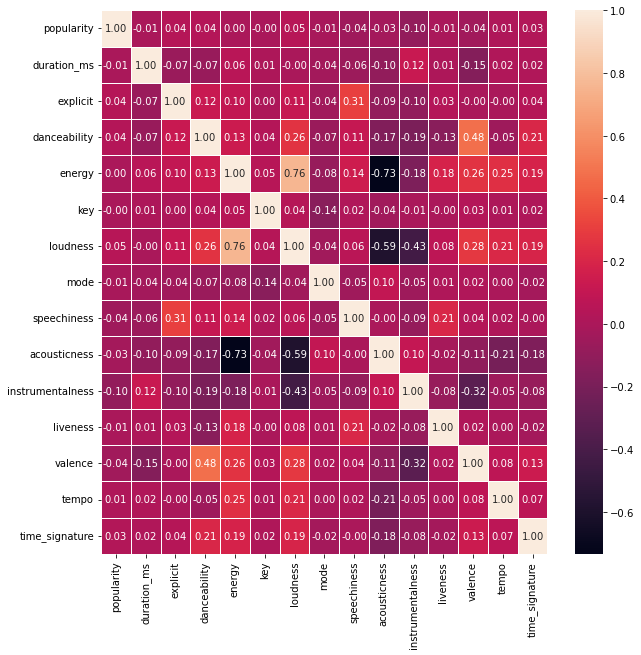

In [276]:
correlation_matrix = songs.corr()
fig, ax = plt.subplots(figsize=(10,10))
sn.heatmap(correlation_matrix, annot=True, linewidth=1, fmt=".2f")

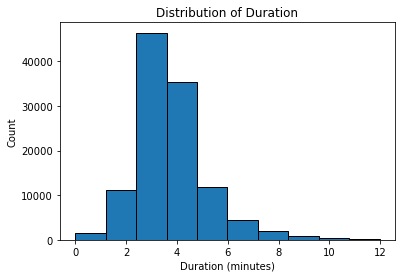

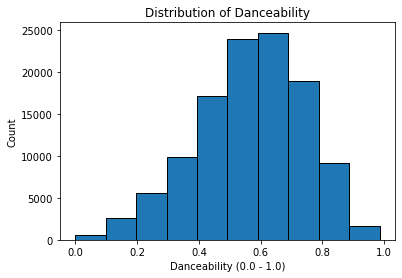

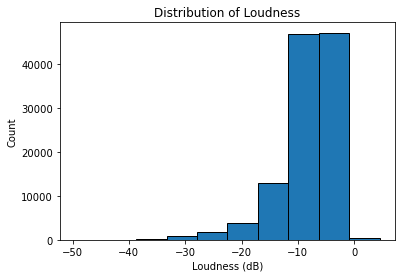

In [277]:
# generate histograms
plot_utils.make_histogram(duration_minutes, "Distribution of Duration", "Duration (minutes)", "Count")
plot_utils.make_histogram(danceability, "Distribution of Danceability", "Danceability (0.0 - 1.0)", "Count")
plot_utils.make_histogram(loudness, "Distribution of Loudness", "Loudness (dB)", "Count")

## Train/Test Set Building
Using stratified k-fold cross validation (with k=10).

In [278]:
y = np.array(songs.pop("popularity"))
X = np.array(songs)

## Regressor Initialization
Comparing the performance of the KNN regressor, SGD regressor, and decision tree regressor, with a linear regressor as a baseline.

## Regressor Evaluation
Using the following metrics:
* Accuracy and error rate
* Precision, recall, and F1 measure